[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Implementation of Linear Regression using PyTorch APIs

Deep learning has witnessed an explosion over the past decade.
The sheer number of techniques, applications and algorithms by far surpasses the
progress of previous decades. 
This is due to a fortuitous combination of multiple factors,
one of which is the powerful free tools
offered by a number of open-source deep learning frameworks.
Theano and Caffe represent the first generation of such models 
that found widespread adoption.
These modern frameworks offer automatic differentiation
and the convenience of Python.
These frameworks allow us to automate and modularize
the repetitive work of implementing gradient-based learning algorithms.

In the previous notebook we relied only on
(i) tensors for data storage and linear algebra;
and (ii) automatic differentiation for calculating gradients.
In practice, because data iterators, loss functions, optimizers,
and neural network layers are so common, modern libraries implement these components for us as well.
In this notebook, **we will implement the linear regression model concisely by using the high-level API** of PyTorch.

In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0);   # for reproducibility

## Defining the Model

When we implemented linear regression from scratch, we defined our model parameters explicitly and coded the calculations to produce network output
using basic linear algebra operations.
Next, we will do the same with the functionality provided by PyTorch.
In general, this allows us to focus on model architecture
rather than worrying about the implementation.
For our single neuron architecture we will use a *fully connected* layer where each of its inputs is connected to each of its outputs, and its output is computed  by means of a matrix-vector multiplication.

In PyTorch, a fully connected layer is defined in the `Linear` and `LazyLinear` classes (available since version 1.8.0). 
`LazyLinear` allows users to specify only the output dimension, while `Linear`
requires the number of inputs to a layer.
Specifying input shapes is inconvenient and may require nontrivial calculations
(such as in convolutional layers).  Thus, for simplicity, we often use "lazy" layers.


In [2]:
class LinearRegression(nn.Module):  
    """The linear regression model implemented with the PyTorch high-level API."""
    def __init__(self):
        super().__init__()
        self.net = nn.LazyLinear(1)
        # alternative is to use nn.Linear(num_in, num_out)
        # LazyLinear does not initialize the weights until the network's
        # forward function is first called
        # the setting of the seed ensures that the weights are initialized
        # in a consistent way across runs
    def forward(self, X):
        return self.net(X)        

In the `forward` method the call `self.net(X)` invokes the built-in `__call__` method of the predefined layers to compute the output.


Let's create an instance of LinearRegression:

In [3]:
model = LinearRegression()


And take a look at the instance we just created:

In [4]:
model

LinearRegression(
  (net): LazyLinear(in_features=0, out_features=1, bias=True)
)

In [5]:
model.net

LazyLinear(in_features=0, out_features=1, bias=True)

## Defining the Loss Function


The PyTorch `MSELoss` class computes the mean squared error (without the $1/2$ factor).
By default, `MSELoss` returns the average loss over examples.

In [6]:
loss_fn = nn.MSELoss()

## Defining the Optimization Algorithm


Minibatch SGD is a standard tool
for optimizing neural networks
and thus PyTorch supports it alongside a number of
variations in the `optim` module.
When we create an instance of `SGD`,
we specify the parameters to optimize over,
obtainable from our model via `model.parameters()`,
and the learning rate.

In [7]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

## Training

Expressing our model using PyTorch
requires fewer lines of code.
We did not have to allocate parameters individually,
define our loss function, or implement minibatch SGD.

Now that we have all the basic pieces in place,
the training loop itself is the same
as the one we implemented from scratch.

### The Data

We reuse the **same synthetic dataset** as in the from-scratch notebook, generated
from a known linear model

$$\mathbf{y} = \mathbf{X}\mathbf{w} + b + \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2),$$

with ground-truth parameters $\mathbf{w} = [2.0, -3.4]^\top$ and $b = 4.2$. Because we
know the true parameters, we can check at the end how well training recovers them.
Using identical data and the same seed lets us compare this concise implementation
directly against the from-scratch one.

One subtlety worth noting: `synthetic_data` returns the targets `y` with shape
`(num_examples, 1)`, i.e. as a column vector. This matters because `nn.MSELoss` does
**not** require its two arguments to have the same shape. If the predictions (shape
`[batch, 1]`) and the targets (shape `[batch]`) differ, broadcasting silently produces
a `[batch, batch]` matrix of differences and a meaningless loss — with no error raised.
Keeping the targets as a column vector keeps the prediction and target shapes aligned.


In [8]:
# Synthetic data generator (identical to the from-scratch notebook).
# We sample features from a standard normal distribution and generate
# labels from a KNOWN linear model y = X w + b + noise.
def synthetic_data(w, b, num_examples, noise=0.1):
    """Generate y = X w + b + noise, with w a 1D tensor of true weights."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w.reshape(-1, 1)) + b
    y += torch.normal(0, noise, y.shape)
    return X, y

# Ground-truth parameters
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

torch.manual_seed(0)  # for reproducibility (matches the from-scratch notebook)
X_train, y_train = synthetic_data(true_w, true_b, num_examples=1000, noise=0.1)
X_val,   y_val   = synthetic_data(true_w, true_b, num_examples=200,  noise=0.1)

print("True w:", true_w.tolist(), " True b:", true_b)
print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)

# Create TensorDataset and DataLoader for training and validation
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)


True w: [2.0, -3.4000000953674316]  True b: 4.2
X_train shape: torch.Size([1000, 2])  y_train shape: torch.Size([1000, 1])


In [9]:
model = LinearRegression()
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)


In [10]:
# training loop
epochs = 10
loss_train = []  # track training loss
loss_valid = []  # track validation loss

for epoch in range(epochs):
    # training phase
    model.train()   # set train mode (no effect here, but matters once we add dropout / batchnorm)
    loss_values = []  # track batch losses during training
    
    for batch_X, batch_y in train_dataloader:
        preds = model(batch_X)            # use __call__, not .forward(): runs hooks & lazy init
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # mean training loss for the epoch
    loss_train.append(np.mean(loss_values))
    
    # validation phase
    model.eval()    # set eval mode (again a no-op here, but good practice)
    loss_values = []  # track batch losses during validation
    
    for batch_X, batch_y in val_dataloader:
        # disable gradient calculations during validation
        with torch.no_grad():
            preds = model(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
    
    # mean validation loss for the epoch
    loss_valid.append(np.mean(loss_values))
    
    print(f"Epoch {epoch + 1}: Training Loss = {loss_train[-1]:.4f}, Validation Loss = {loss_valid[-1]:.4f}")


Epoch 1: Training Loss = 10.0354, Validation Loss = 0.8583
Epoch 2: Training Loss = 0.2161, Validation Loss = 0.0297
Epoch 3: Training Loss = 0.0134, Validation Loss = 0.0102
Epoch 4: Training Loss = 0.0094, Validation Loss = 0.0094
Epoch 5: Training Loss = 0.0094, Validation Loss = 0.0095
Epoch 6: Training Loss = 0.0093, Validation Loss = 0.0095
Epoch 7: Training Loss = 0.0093, Validation Loss = 0.0094
Epoch 8: Training Loss = 0.0093, Validation Loss = 0.0093
Epoch 9: Training Loss = 0.0093, Validation Loss = 0.0096
Epoch 10: Training Loss = 0.0093, Validation Loss = 0.0093


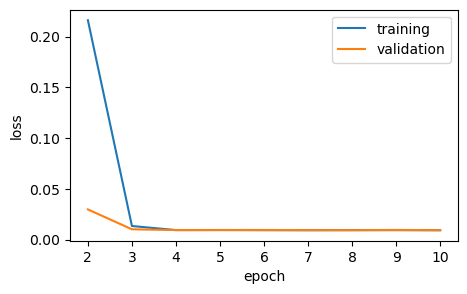

In [11]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(range(2, len(loss_train)+1), loss_train[1:], label='training')
plt.plot(range(2, len(loss_valid)+1), loss_valid[1:], label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend();

Observe that the network now has a well-defined Linear layer:

In [12]:
model

LinearRegression(
  (net): Linear(in_features=2, out_features=1, bias=True)
)

And we can extract its weights. Because we generated the data from known
parameters, we can compare the learned values against the ground truth — the
same check we made in the from-scratch notebook:


In [13]:
w_est = model.net.weight.data.reshape(-1)
b_est = model.net.bias.data.item()

print("Estimated w:", w_est.tolist())
print("True      w:", true_w.tolist())
print("Estimated b:", b_est)
print("True      b:", true_b)


Estimated w: [1.998081088066101, -3.394582509994507]
True      w: [2.0, -3.4000000953674316]
Estimated b: 4.201335906982422
True      b: 4.2


## Summary

This notebook is our first implementation of a deep network to tap into the conveniences afforded by modern deep learning frameworks such as PyTorch.
We used PyTorch functionality for loading data, defining a layer,
a loss function, an optimizer and a training loop.
Whenever the framework provides all necessary features,
it is generally a good idea to use them,
since the library implementations of these components
tend to be heavily optimized for performance
and properly tested for reliability.
At the same time, try not to forget
that these modules *can* be implemented directly.
This is especially important for aspiring researchers
who wish to live on the leading edge of model development,
where you will be inventing new components
that do not exist in any current library.


## Exercises

1. The Huber robust loss function is an alternative to the squared error loss function. It is defined as:
   $$l(y,y') = \begin{cases}|y-y'| -\frac{\delta}{2} & \textrm{ if } |y-y'| > \delta \\ \frac{1}{2 \delta} (y-y')^2 & \textrm{ otherwise}\end{cases}$$
   Replace `nn.MSELoss` with PyTorch's built-in Huber loss (`nn.HuberLoss`),  and retrain. How does the learned solution change, and how does it respond if you add a few large outliers to the training targets?
2. How do you access the gradient of the weights of the model?
3. What is the effect on the solution if you change the learning rate and the number of epochs?
4. Apply the network to the diabetes dataset. Is it behaving in the same way as our implementation from scratch?
